#Step 1. Load Dataset

In [2]:
import pandas as pd

# 1. Load the main dataset and the mapping dataset
df = pd.read_csv('diabetic_data.csv')
ids_mapping = pd.read_csv('IDS_mapping.csv')

# 2. Inspect the shape (number of rows and columns)
print(f"Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns")

# 3. Check the first 5 rows to see what the raw data looks like
display(df.head())

# 4. Check data types and see if Pandas recognizes any missing values initially
print("\n--- Data Info ---")
df.info()

Dataset Shape: 101766 rows and 50 columns


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO



--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-nul

#Step 2. Basic Data Cleaning

Following the methodology of the original dataset authors, we retained only the first encounter per patient to ensure statistical independence of observations, consistent with prior work using this dataset, and to avoid potential leakage across repeated hospital visits.

In [3]:
import numpy as np

# 1. Replace the '?' markers with standard Pandas NaN
df.replace('?', np.nan, inplace=True)

# 2. Remove any perfectly duplicated rows
df.drop_duplicates(inplace=True)

# 3. Keep only the first encounter for each patient
# (This matches the original dataset paper's methodology and prevents data leakage)
df = df.drop_duplicates(subset=['patient_nbr'], keep='first')

# 4. Create the binary target variable for 30-day readmission
# 1 = Readmitted within 30 days ('<30')
# 0 = Not readmitted within 30 days ('>30' or 'NO')
df['readmitted_30d'] = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

# 5. Drop identifiers and the original target column
df.drop(columns=['encounter_id', 'patient_nbr', 'readmitted'], inplace=True)

# 6. Drop columns that are extremely sparse (missing too much data)
df.drop(columns=['weight', 'medical_specialty', 'payer_code'], inplace=True)

# --- Verification ---
print(f"Dataset Shape after basic cleaning: {df.shape[0]} rows and {df.shape[1]} columns")

print("\n--- Missing Values Count (Top 10) ---")
print(df.isnull().sum().sort_values(ascending=False).head(10))

print("\n--- Target Variable Distribution (%) ---")
print(df['readmitted_30d'].value_counts(normalize=True) * 100)

Dataset Shape after basic cleaning: 71518 rows and 45 columns

--- Missing Values Count (Top 10) ---
max_glu_serum          68062
A1Cresult              58532
race                    1948
diag_3                  1225
diag_2                   294
diag_1                    11
admission_source_id        0
num_lab_procedures         0
time_in_hospital           0
gender                     0
dtype: int64

--- Target Variable Distribution (%) ---
readmitted_30d
0    91.200817
1     8.799183
Name: proportion, dtype: float64


#Step 3. Exploratory Data Analysis (EDA)

##3.1 Data Overview

             NUMERICAL DATA SUMMARY               


,count,mean,std,min,25%,50%,75%,max
admission_type_id,71518.0,2.100254,1.508301,1.0,1.0,1.0,3.0,8.0
discharge_disposition_id,71518.0,3.593235,5.269771,1.0,1.0,1.0,3.0,28.0
admission_source_id,71518.0,5.657457,4.162580,1.0,1.0,7.0,7.0,25.0
time_in_hospital,71518.0,4.289130,2.949210,1.0,2.0,3.0,6.0,14.0
num_lab_procedures,71518.0,43.075478,19.952338,1.0,31.0,44.0,57.0,132.0
num_procedures,71518.0,1.430577,1.759864,0.0,0.0,1.0,2.0,6.0
num_medications,71518.0,15.705025,8.311163,1.0,10.0,14.0,20.0,81.0
number_outpatient,71518.0,0.280069,1.068957,0.0,0.0,0.0,0.0,42.0
number_emergency,71518.0,0.103540,0.509187,0.0,0.0,0.0,0.0,42.0
number_inpatient,71518.0,0.177829,0.603790,0.0,0.0,0.0,0.0,12.0



             CATEGORICAL DATA SUMMARY             


,count,unique,top,freq
race,69570,5,Caucasian,53491
gender,71518,3,Female,38025
age,71518,10,[70-80),18210
diag_1,71507,696,414,5233
diag_2,71224,725,250,5009
diag_3,70293,758,250,9039
max_glu_serum,3456,3,Norm,1731
A1Cresult,12986,3,>8,6304
metformin,71518,4,No,56527
repaglinide,71518,4,No,70592


/tmp/ipykernel_2503/4135229001.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='readmitted_30d', order=df['readmitted_30d'].value_counts().index, palette='Set2')


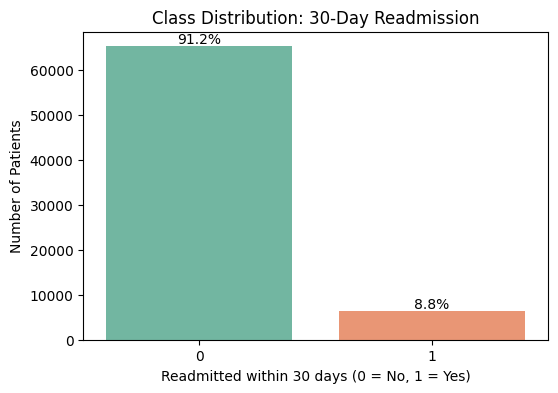

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Numerical Data Summary
print("==================================================")
print("             NUMERICAL DATA SUMMARY               ")
print("==================================================")
# .T transposes the table to make it easier to read left-to-right
display(df.describe().T)

# 2. Categorical Data Summary
print("\n==================================================")
print("             CATEGORICAL DATA SUMMARY             ")
print("==================================================")
display(df.describe(include=['object']).T)

# 3. Class Distribution Visualization
plt.figure(figsize=(6, 4))
# Sorting the bars so the largest class is first
ax = sns.countplot(data=df, x='readmitted_30d', order=df['readmitted_30d'].value_counts().index, palette='Set2')
plt.title('Class Distribution: 30-Day Readmission')
plt.xlabel('Readmitted within 30 days (0 = No, 1 = Yes)')
plt.ylabel('Number of Patients')

# Adding percentage labels on top of the bars
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.show()

##3.2 Missing Values Analysis

             MISSING VALUES ANALYSIS              


,Feature,Missing_Count,Missing_Percent
0,max_glu_serum,68062,95.167650
1,A1Cresult,58532,81.842333
2,race,1948,2.723790
3,diag_3,1225,1.712856
4,diag_2,294,0.411085
5,diag_1,11,0.015381


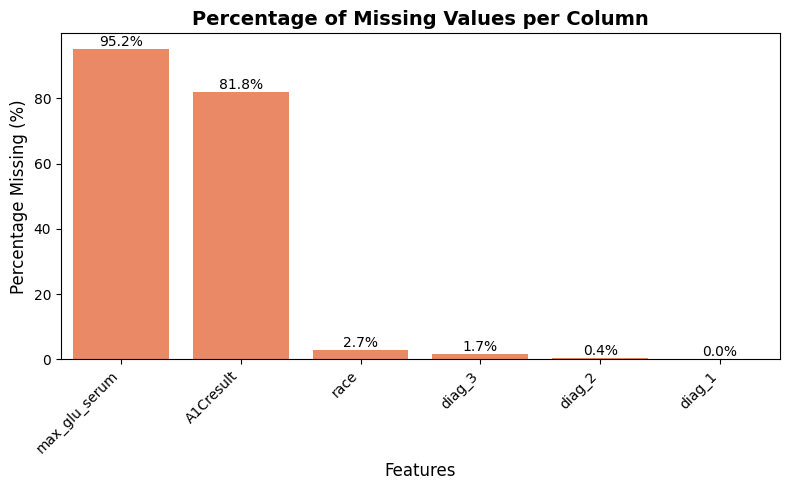

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate missing counts and percentages
missing_counts = df.isnull().sum()
missing_percent = (missing_counts / len(df)) * 100

# 2. Create a DataFrame for easier viewing
missing_df = pd.DataFrame({
    'Missing_Count': missing_counts,
    'Missing_Percent': missing_percent
})

# Filter only columns that actually have missing values and sort them
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values(by='Missing_Percent', ascending=False)
missing_df = missing_df.reset_index().rename(columns={'index': 'Feature'})

print("==================================================")
print("             MISSING VALUES ANALYSIS              ")
print("==================================================")
display(missing_df)

# 3. Visualize the missingness (Instructor Requirement)
if not missing_df.empty:
    plt.figure(figsize=(8, 5))

    # Create a bar plot
    ax = sns.barplot(x='Feature', y='Missing_Percent', data=missing_df, color='coral')

    plt.title('Percentage of Missing Values per Column', fontsize=14, fontweight='bold')
    plt.xlabel('Features', fontsize=12)
    plt.ylabel('Percentage Missing (%)', fontsize=12)

    # Rotate x-axis labels so they don't overlap
    plt.xticks(rotation=45, ha='right')

    # Add exact percentage labels on top of the bars
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.show()
else:
    print("\nNo missing values found in the dataset!")

##3.3 Univariate Analysis

             UNIVARIATE ANALYSIS                  


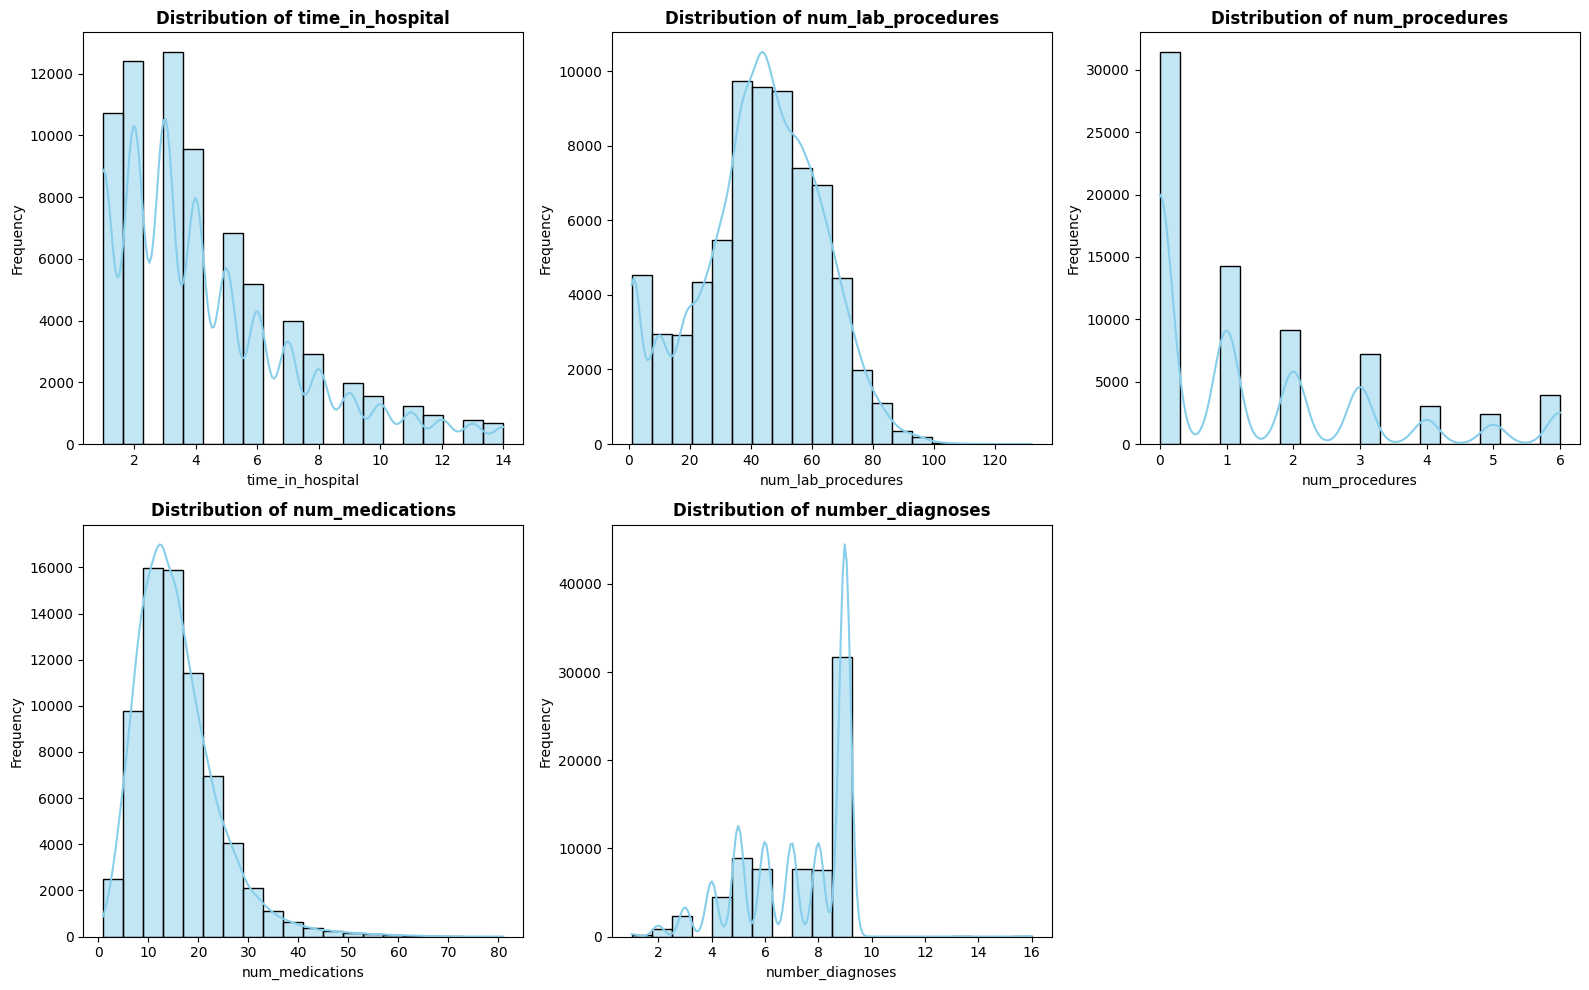

/tmp/ipykernel_2503/2601719465.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_diagnoses.index, y=top_diagnoses.values, palette='magma')


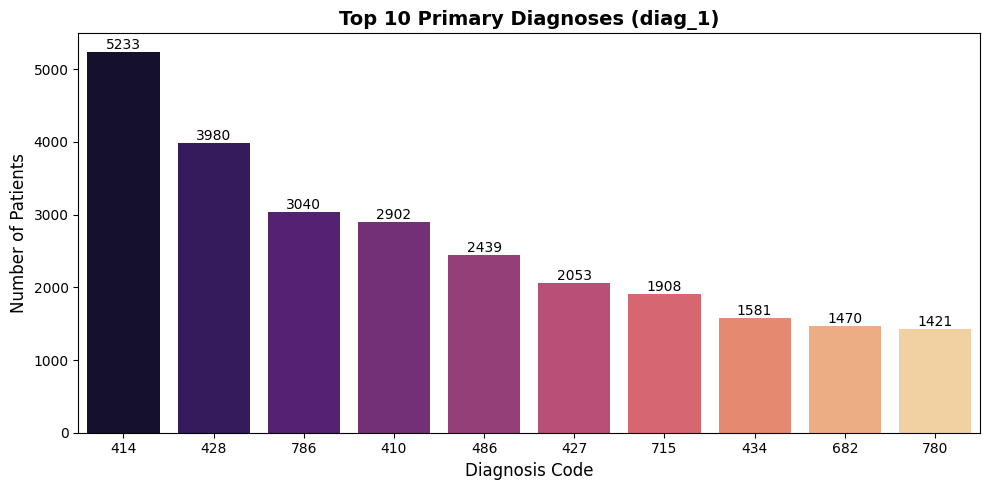

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

print("==================================================")
print("             UNIVARIATE ANALYSIS                  ")
print("==================================================")

# 1. Select the key numerical columns to visualize
numerical_cols = ['time_in_hospital', 'num_lab_procedures',
                  'num_procedures', 'num_medications', 'number_diagnoses']

# 2. Plot Histograms for numerical features (Instructor Requirement)
plt.figure(figsize=(16, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    # Using kde=True adds a smooth distribution line over the histogram
    sns.histplot(df[col], kde=True, bins=20, color='skyblue')
    plt.title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# 3. Categorical Univariate Analysis: Top 10 Primary Diagnoses (diag_1)
plt.figure(figsize=(10, 5))
# Getting the top 10 most frequent diagnoses
top_diagnoses = df['diag_1'].value_counts().head(10)

ax = sns.barplot(x=top_diagnoses.index, y=top_diagnoses.values, palette='magma')
plt.title('Top 10 Primary Diagnoses (diag_1)', fontsize=14, fontweight='bold')
plt.xlabel('Diagnosis Code', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)

# Adding the exact count on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

##3.4 Outlier Detection

             OUTLIER DETECTION                    


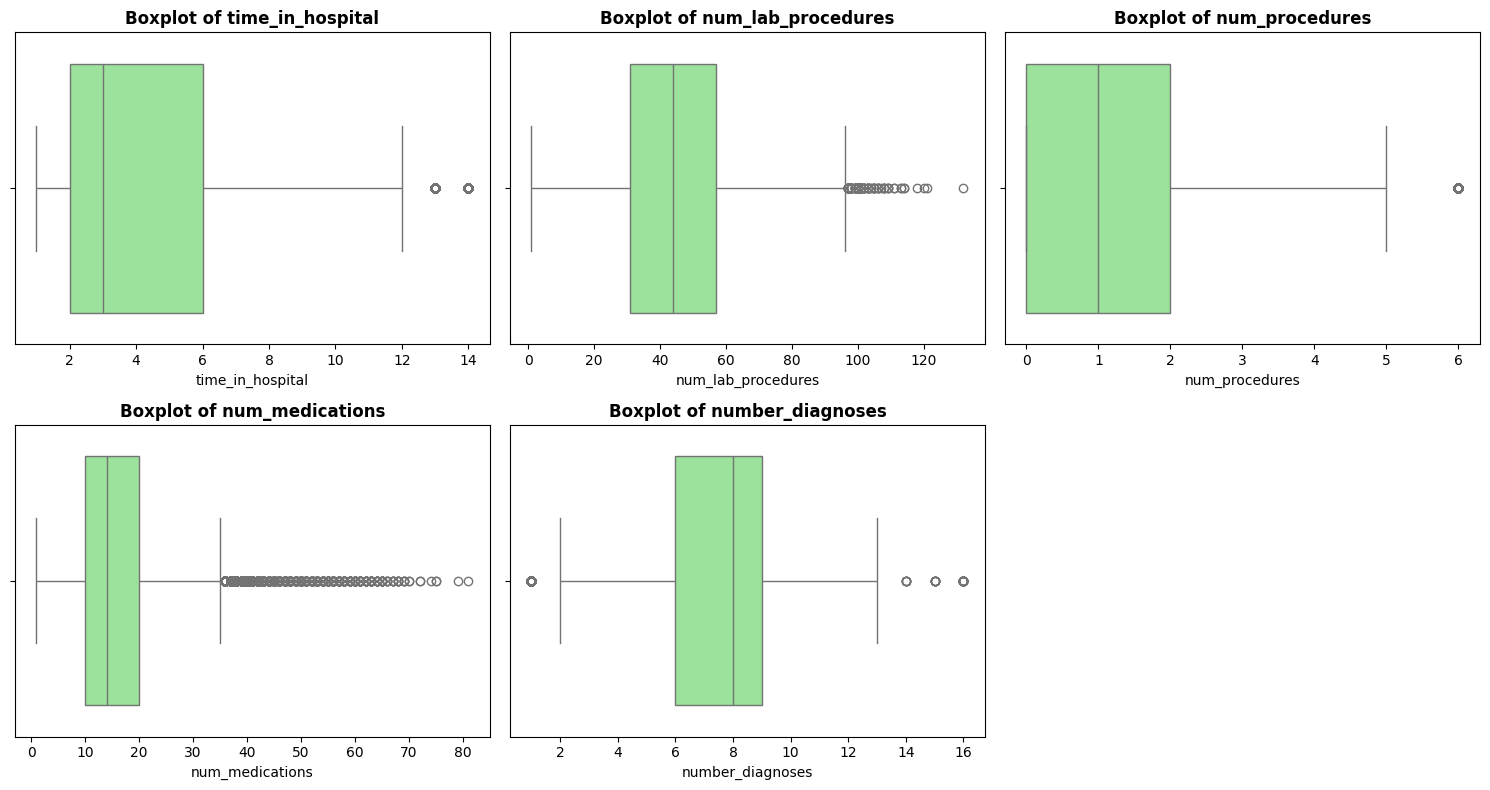


IQR Analysis for 'num_medications':
- Normal range is between -5.0 and 35.0 medications.
- Found 1925 outliers outside this range.
- The maximum medications given to a single patient was 81.


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

print("==================================================")
print("             OUTLIER DETECTION                    ")
print("==================================================")

# 1. Select continuous numerical features for boxplots
outlier_cols = ['time_in_hospital', 'num_lab_procedures',
                'num_procedures', 'num_medications', 'number_diagnoses']

# 2. Visualize Outliers using Boxplots (Instructor Requirement)
plt.figure(figsize=(15, 8))
for i, col in enumerate(outlier_cols, 1):
    plt.subplot(2, 3, i)
    # Using a horizontal boxplot for better readability
    sns.boxplot(x=df[col], color='lightgreen')
    plt.title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
    plt.xlabel(col)

plt.tight_layout()
plt.show()

# 3. Optional but recommended: IQR Outlier Count for 'num_medications'
def count_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = dataframe[(dataframe[column] < lower_bound) | (dataframe[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

med_outliers, med_lower, med_upper = count_outliers_iqr(df, 'num_medications')
print(f"\nIQR Analysis for 'num_medications':")
print(f"- Normal range is between {med_lower} and {med_upper} medications.")
print(f"- Found {med_outliers} outliers outside this range.")
print(f"- The maximum medications given to a single patient was {df['num_medications'].max()}.")

##3.5 Feature Relationships

       FEATURE RELATIONSHIPS (CORRELATION)        


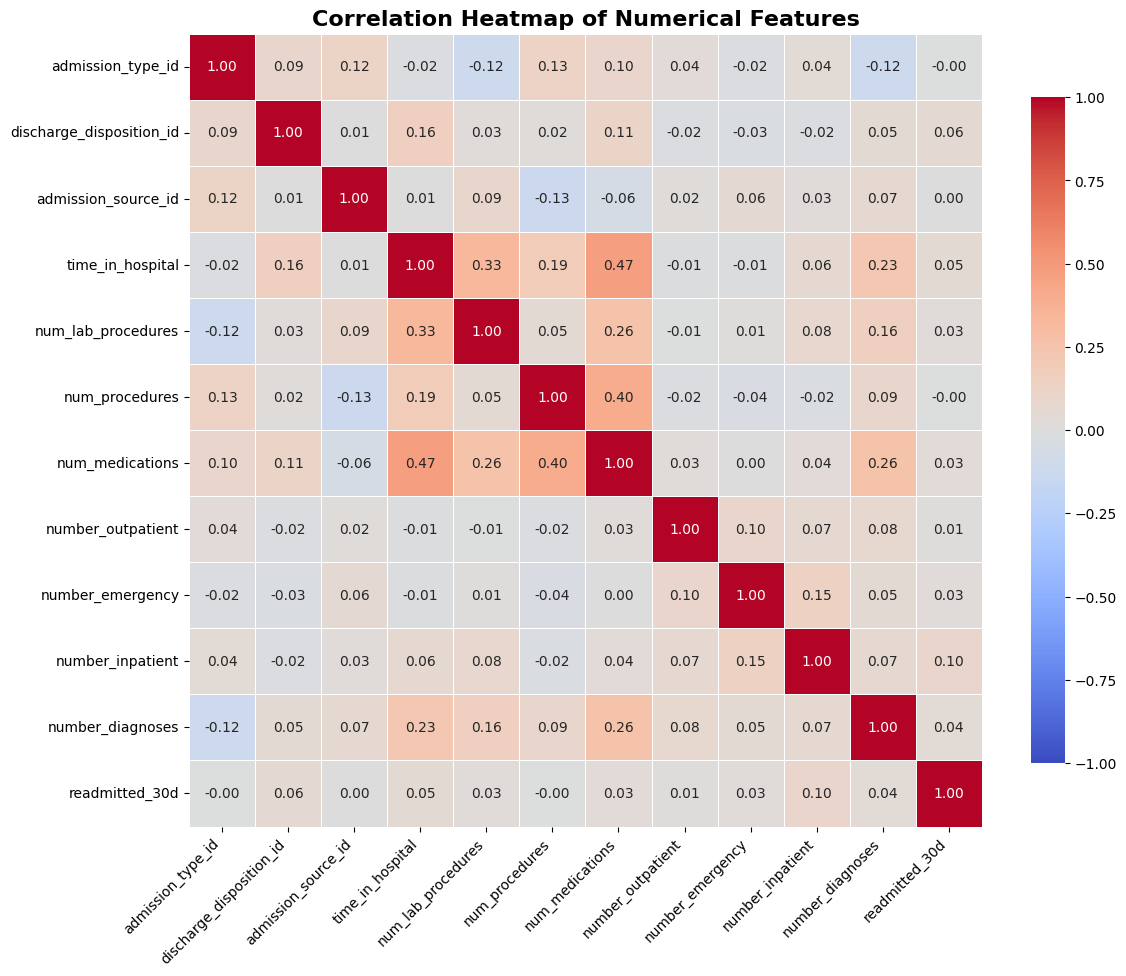

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

print("==================================================")
print("       FEATURE RELATIONSHIPS (CORRELATION)        ")
print("==================================================")

# 1. Select only numerical columns for the correlation matrix
# (Correlation only mathematically works on numbers, not text like 'race')
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# 2. Calculate the correlation matrix
corr_matrix = numeric_df.corr()

# 3. Plot the Heatmap (Instructor Requirement)
plt.figure(figsize=(12, 10))

# annot=True puts the exact numbers in the squares
# cmap='coolwarm' uses a color scale where Red is positive correlation and Blue is negative
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm',
            square=True, linewidths=.5, vmin=-1, vmax=1, cbar_kws={"shrink": .8})

plt.title('Correlation Heatmap of Numerical Features', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#Step 4. Train / Validation / Test Split

In [9]:
from sklearn.model_selection import train_test_split

print("==================================================")
print("        TRAIN / VALIDATION / TEST SPLIT           ")
print("==================================================")

# 1. Separate Features (X) and Target (y)
X = df.drop(columns=['readmitted_30d'])
y = df['readmitted_30d']

# 2. First split: Separate out the Test set (15% of total data)
# Using stratify=y ensures all splits have the same 91%/9% class balance!
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# 3. Second split: Split the remaining 85% into Train (70%) and Validation (15%)
# To get 15% of the total dataset from the 85% temp set, test_size needs to be (0.15 / 0.85)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=(0.15 / 0.85), random_state=42, stratify=y_temp
)

# 4. Verify the shapes and distribution
print(f"Original dataset: {df.shape[0]} rows")
print(f"Training set:     {X_train.shape[0]} rows ({len(X_train)/len(df)*100:.1f}%)")
print(f"Validation set:   {X_val.shape[0]} rows ({len(X_val)/len(df)*100:.1f}%)")
print(f"Test set:         {X_test.shape[0]} rows ({len(X_test)/len(df)*100:.1f}%)")

print("\n--- Target Distribution in Training Set (%) ---")
print(y_train.value_counts(normalize=True) * 100)

        TRAIN / VALIDATION / TEST SPLIT           
Original dataset: 71518 rows
Training set:     50062 rows (70.0%)
Validation set:   10728 rows (15.0%)
Test set:         10728 rows (15.0%)

--- Target Distribution in Training Set (%) ---
readmitted_30d
0    91.200911
1     8.799089
Name: proportion, dtype: float64


#Step 5. Missing Value Handling

In [10]:
import pandas as pd

print("==================================================")
print("             MISSING VALUE HANDLING               ")
print("==================================================")

# 1. Handle Medical Tests (Constant Imputation)
# 'Not Measured' becomes a new category indicating the doctor didn't order the test
for df_split in [X_train, X_val, X_test]:
    df_split['max_glu_serum'] = df_split['max_glu_serum'].fillna('Not Measured')
    df_split['A1Cresult'] = df_split['A1Cresult'].fillna('Not Measured')

# 2. Handle standard categorical columns (Mode Imputation)
cols_to_impute = ['race', 'diag_1', 'diag_2', 'diag_3']

for col in cols_to_impute:
    # Calculate the mode ONLY from the training data!
    # [0] gets the most frequent string
    train_mode = X_train[col].mode()[0]

    # Apply this learned mode to train, val, and test sets
    X_train[col] = X_train[col].fillna(train_mode)
    X_val[col] = X_val[col].fillna(train_mode)
    X_test[col] = X_test[col].fillna(train_mode)

# 3. Final Verification
print("Missing values in X_train after imputation:")
print(X_train.isnull().sum().sum())  # Should be 0

print("Missing values in X_val after imputation:")
print(X_val.isnull().sum().sum())    # Should be 0

print("Missing values in X_test after imputation:")
print(X_test.isnull().sum().sum())   # Should be 0

print("\n--- Example: A1Cresult distribution in Training Set ---")
print(X_train['A1Cresult'].value_counts())

             MISSING VALUE HANDLING               
Missing values in X_train after imputation:
0
Missing values in X_val after imputation:
0
Missing values in X_test after imputation:
0

--- Example: A1Cresult distribution in Training Set ---
A1Cresult
Not Measured    40935
>8               4441
Norm             2654
>7               2032
Name: count, dtype: int64


Step 5.1: Exporting the Cleaned Data

In [11]:
print("==================================================")
print("             EXPORTING DATA                       ")
print("==================================================")

# Save the feature sets (X)
X_train.to_csv('X_train_cleaned.csv', index=False)
X_val.to_csv('X_val_cleaned.csv', index=False)
X_test.to_csv('X_test_cleaned.csv', index=False)

# Save the target sets (y)
y_train.to_csv('y_train.csv', index=False)
y_val.to_csv('y_val.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

print("Success! All datasets have been saved to your Colab environment.")
print("You can now download these and share them with your teammate!")

             EXPORTING DATA                       
Success! All datasets have been saved to your Colab environment.
You can now download these and share them with your teammate!


#Step 6. Categorical Encoding

In [19]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
import numpy as np

print("==================================================")
print("           STEP 6: CATEGORICAL ENCODING           ")
print("==================================================")

# Categorical columns

categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

print(f"\nCategorical columns found: {categorical_cols}")
print(f"Number of categorical columns: {len(categorical_cols)}")

# Fit OneHotEncoder on TRAINING data only
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder.fit(X_train[categorical_cols])


encoded_feature_names = encoder.get_feature_names_out(categorical_cols)


X_train_encoded = encoder.transform(X_train[categorical_cols])
X_val_encoded = encoder.transform(X_val[categorical_cols])
X_test_encoded = encoder.transform(X_test[categorical_cols])



           STEP 6: CATEGORICAL ENCODING           

Categorical columns found: []
Number of categorical columns: 0


In [20]:
# Convert to DataFrames
X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=encoded_feature_names, index=X_train.index)
X_val_encoded_df = pd.DataFrame(X_val_encoded, columns=encoded_feature_names, index=X_val.index)
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=encoded_feature_names, index=X_test.index)

# (already numeric, no encoding needed)
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

print(f"\nNumeric columns (no encoding needed): {numeric_cols}")

# Numeric + encoded categorical columns
X_train = pd.concat([X_train[numeric_cols].reset_index(drop=True),
                      X_train_encoded_df.reset_index(drop=True)], axis=1)
X_val = pd.concat([X_val[numeric_cols].reset_index(drop=True),
                    X_val_encoded_df.reset_index(drop=True)], axis=1)
X_test = pd.concat([X_test[numeric_cols].reset_index(drop=True),
                     X_test_encoded_df.reset_index(drop=True)], axis=1)


Numeric columns (no encoding needed): ['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'race_AfricanAmerican', 'race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Other', 'gender_Female', 'gender_Male', 'gender_Unknown/Invalid', 'age_[0-10)', 'age_[10-20)', 'age_[20-30)', 'age_[30-40)', 'age_[40-50)', 'age_[50-60)', 'age_[60-70)', 'age_[70-80)', 'age_[80-90)', 'age_[90-100)', 'diag_1_11', 'diag_1_110', 'diag_1_112', 'diag_1_114', 'diag_1_115', 'diag_1_117', 'diag_1_133', 'diag_1_135', 'diag_1_136', 'diag_1_141', 'diag_1_142', 'diag_1_146', 'diag_1_147', 'diag_1_149', 'diag_1_150', 'diag_1_151', 'diag_1_152', 'diag_1_153', 'diag_1_154', 'diag_1_155', 'diag_1_156', 'diag_1_157', 'diag_1_158', 'diag_1_161', 'diag_1_162', 'diag_1_163', 'diag_1_164', 'diag_1_170', 'diag_1_171', 'diag_1_172', 'diag_1_173', 

In [17]:
print(f"\nAfter encoding:")
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")

print(f"\nAll columns are now numeric: {X_train.dtypes.unique()}")

print("\n✓ Categorical encoding completed successfully!")


After encoding:
X_train shape: (50062, 2136)
X_val shape: (10728, 2136)
X_test shape: (10728, 2136)

All columns are now numeric: [dtype('int64') dtype('float64')]

✓ Categorical encoding completed successfully!


#Step 7. Feature Scaling

In [21]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

print("==================================================")
print("             STEP 7: FEATURE SCALING              ")
print("==================================================")



scaler = StandardScaler()
scaler.fit(X_train)

print(f"\nScaler fitted on training data:")
print(f"  - Training set shape: {X_train.shape}")
print(f"  - Number of features: {X_train.shape[1]}")


X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

             STEP 7: FEATURE SCALING              

Scaler fitted on training data:
  - Training set shape: (50062, 2136)
  - Number of features: 2136


In [22]:

X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_val = pd.DataFrame(X_val_scaled, columns=X_val.columns, index=X_val.index)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print(f"\nAfter scaling:")
print(f"X_train - Mean: {X_train.mean().mean():.6f}, Std: {X_train.std().mean():.6f}")
print(f"X_val   - Mean: {X_val.mean().mean():.6f}, Std: {X_val.std().mean():.6f}")
print(f"X_test  - Mean: {X_test.mean().mean():.6f}, Std: {X_test.std().mean():.6f}")




After scaling:
X_train - Mean: 0.000000, Std: 0.998137
X_val   - Mean: 0.000278, Std: 0.804178
X_test  - Mean: -0.000114, Std: 0.785077


In [24]:
print("\nScaling Statistics (on training set):")
print(f"  Feature means (first 5): {scaler.mean_[:5]}")
print(f"  Feature stds (first 5): {scaler.scale_[:5]}")

print("\n✓ Feature scaling completed successfully!")
print("\nNote: All three sets use the SAME scaler (fitted on training data only)")


Scaling Statistics (on training set):
  Feature means (first 5): [ 2.10481004  3.58871     5.64775678  4.28095162 43.06591826]
  Feature stds (first 5): [ 1.51013688  5.27466126  4.16114169  2.9428302  19.95658789]

✓ Feature scaling completed successfully!

Note: All three sets use the SAME scaler (fitted on training data only)


#Step 8. Adversarial Condition Injection

In [28]:
from imblearn.over_sampling import SMOTE
import pandas as pd

print("==================================================")
print("   STEP 8: ADVERSARIAL CONDITION INJECTION        ")
print("==================================================")

# CHOSEN STRATEGY: Class Imbalance Handling using SMOTE



print("\nTarget variable distribution BEFORE SMOTE:")
print(y_train.value_counts())
print(f"\nClass distribution ratio:")
print(y_train.value_counts(normalize=True))

# Apply SMOTE only to TRAINING set
smote = SMOTE(random_state=42, k_neighbors=5)


   STEP 8: ADVERSARIAL CONDITION INJECTION        

Target variable distribution BEFORE SMOTE:
readmitted_30d
0    45657
1     4405
Name: count, dtype: int64

Class distribution ratio:
readmitted_30d
0    0.912009
1    0.087991
Name: proportion, dtype: float64


In [27]:
# Apply SMOTE only to TRAINING set
smote = SMOTE(random_state=42, k_neighbors=5)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"\n\nTarget variable distribution AFTER SMOTE:")
print(y_train_smote.value_counts())
print(f"\nClass distribution ratio after SMOTE:")
print(y_train_smote.value_counts(normalize=True))

print(f"\nTraining set sizes:")
print(f"  Before SMOTE: {X_train.shape[0]} samples")
print(f"  After SMOTE:  {X_train_smote.shape[0]} samples")
print(f"  New samples created: {X_train_smote.shape[0] - X_train.shape[0]}")



Target variable distribution AFTER SMOTE:
readmitted_30d
0    45657
1    45657
Name: count, dtype: int64

Class distribution ratio after SMOTE:
readmitted_30d
0    0.5
1    0.5
Name: proportion, dtype: float64

Training set sizes:
  Before SMOTE: 50062 samples
  After SMOTE:  91314 samples
  New samples created: 41252


In [30]:
X_train = pd.DataFrame(X_train_smote, columns=X_train.columns)
y_train = pd.Series(y_train_smote, name='readmitted')

print("\n✓ SMOTE class balancing completed successfully!")



✓ SMOTE class balancing completed successfully!


#Step 9. Final Dataset Preparation

In [31]:
import pandas as pd
import numpy as np

print("==================================================")
print("    STEP 9: FINAL DATASET PREPARATION             ")
print("==================================================")

# Final Validation Checklist
print("\n[1] CHECKING FOR MISSING VALUES...")
print(f"    X_train missing values: {X_train.isnull().sum().sum()}")
print(f"    X_val missing values: {X_val.isnull().sum().sum()}")
print(f"    X_test missing values: {X_test.isnull().sum().sum()}")
print(f"    y_train missing values: {y_train.isnull().sum()}")
print(f"    y_val missing values: {y_val.isnull().sum()}")
print(f"    y_test missing values: {y_test.isnull().sum()}")

    STEP 9: FINAL DATASET PREPARATION             

[1] CHECKING FOR MISSING VALUES...
    X_train missing values: 0
    X_val missing values: 0
    X_test missing values: 0
    y_train missing values: 0
    y_val missing values: 0
    y_test missing values: 0


In [33]:
missing_count = (X_train.isnull().sum().sum() + X_val.isnull().sum().sum() +
                 X_test.isnull().sum().sum() + y_train.isnull().sum() +
                 y_val.isnull().sum() + y_test.isnull().sum())
if missing_count == 0:
    print("    ✓ No missing values found!")
else:
    print("      WARNING: Missing values detected!")

print("\n[2] CHECKING ALL FEATURES ARE NUMERIC...")
print(f"    X_train data types: {X_train.dtypes.unique()}")
print(f"    X_val data types: {X_val.dtypes.unique()}")
print(f"    X_test data types: {X_test.dtypes.unique()}")

    ✓ No missing values found!

[2] CHECKING ALL FEATURES ARE NUMERIC...
    X_train data types: [dtype('float64')]
    X_val data types: [dtype('float64')]
    X_test data types: [dtype('float64')]


In [34]:
all_numeric = (X_train.dtypes == np.float64).all() and (X_val.dtypes == np.float64).all() and (X_test.dtypes == np.float64).all()
if all_numeric:
    print("    ✓ All features are numeric!")
else:
    print("    ✗ WARNING: Non-numeric features detected!")

print("\n[3] CHECKING CONSISTENT COLUMNS ACROSS SETS...")
print(f"    X_train columns: {X_train.shape[1]}")
print(f"    X_val columns: {X_val.shape[1]}")
print(f"    X_test columns: {X_test.shape[1]}")
if X_train.shape[1] == X_val.shape[1] == X_test.shape[1]:
    print("    ✓ All sets have the same number of features!")
else:
    print("    ✗ WARNING: Inconsistent number of features!")


    ✓ All features are numeric!

[3] CHECKING CONSISTENT COLUMNS ACROSS SETS...
    X_train columns: 2136
    X_val columns: 2136
    X_test columns: 2136
    ✓ All sets have the same number of features!


In [35]:
# Check column names match
if list(X_train.columns) == list(X_val.columns) == list(X_test.columns):
    print("    ✓ All sets have identical feature names!")
else:
    print("    ✗ WARNING: Feature names are different!")

print("\n[4] FINAL DATASET STATISTICS...")
print(f"\nTraining Set:")
print(f"  X_train shape: {X_train.shape}")
print(f"  y_train shape: {y_train.shape}")
print(f"  Class distribution: {y_train.value_counts().to_dict()}")

print(f"\nValidation Set:")
print(f"  X_val shape: {X_val.shape}")
print(f"  y_val shape: {y_val.shape}")
print(f"  Class distribution: {y_val.value_counts().to_dict()}")

    ✓ All sets have identical feature names!

[4] FINAL DATASET STATISTICS...

Training Set:
  X_train shape: (91314, 2136)
  y_train shape: (91314,)
  Class distribution: {0: 45657, 1: 45657}

Validation Set:
  X_val shape: (10728, 2136)
  y_val shape: (10728,)
  Class distribution: {0: 9784, 1: 944}


In [38]:
print(f"\nTest Set:")
print(f"  X_test shape: {X_test.shape}")
print(f"  y_test shape: {y_test.shape}")
print(f"  Class distribution: {y_test.value_counts().to_dict()}")


Test Set:
  X_test shape: (10728, 2136)
  y_test shape: (10728,)
  Class distribution: {0: 9784, 1: 944}


In [41]:
print(f"\nTotal samples across all sets: {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]}")



Total samples across all sets: 112770


In [44]:
X_train.to_csv('X_train_final.csv', index=False)
X_val.to_csv('X_val_final.csv', index=False)
X_test.to_csv('X_test_final.csv', index=False)

y_train.to_csv('y_train_final.csv', index=False)
y_val.to_csv('y_val_final.csv', index=False)
y_test.to_csv('y_test_final.csv', index=False)

print("     Final datasets saved successfully!")
print("\n    Files created:")
print("      - X_train_final.csv")
print("      - X_val_final.csv")
print("      - X_test_final.csv")
print("      - y_train_final.csv")
print("      - y_val_final.csv")
print("      - y_test_final.csv")

print("\n" + "="*50)
print("✓ ALL PREPROCESSING STEPS COMPLETED!")
print("="*50)
print("\nYour data is now ready for model training!")
print("All preprocessing transformations were fit on training data only.")


     Final datasets saved successfully!

    Files created:
      - X_train_final.csv
      - X_val_final.csv
      - X_test_final.csv
      - y_train_final.csv
      - y_val_final.csv
      - y_test_final.csv

✓ ALL PREPROCESSING STEPS COMPLETED!

Your data is now ready for model training!
All preprocessing transformations were fit on training data only.
